<a href="https://colab.research.google.com/github/IsaacFigNewton/Multiplexed-Hypergraph-Visualizer/blob/main/Voronoi_Power_Diagram_View.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classes

## RecursivePowerDiagram

In [16]:
"""
Recursive Voronoi *power diagram* (weighted Voronoi / Laguerre diagram)
where a node's children are visualized as a power diagram clipped to the node region.

- Each internal node is a convex polygon region.
- For each node, we generate one "site" per child *inside* the region.
- Child regions come from the power diagram cells (half-plane intersections).
- Recurse until leaves.

Dependencies: numpy, matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt


class RecursivePowerDiagram:
    """
    Draw a recursive, clipped power diagram to visualize hierarchical containment.

    Parameters
    ----------
    hierarchy : dict
        Mapping from frozenset-like labels to children dictionaries, recursively.
        Example (a tiny tree):
            {
              frozenset({1,2}): { frozenset({1}): {}, frozenset({2}): {} },
              frozenset({3,4}): {}
            }
        Each key becomes one child region of the current node; its value is the
        subtree to recurse into.
    seed : int, default=7
        Seed for deterministic randomness (site placement + weights).
    root : array-like of shape (N, 2), default unit square
        The root convex polygon to clip everything to. Must be convex for
        correct clipping behavior.

    Notes
    -----
    This implementation assumes convex clipping polygons. The power cell for a
    site is computed by intersecting the parent region with a set of half-planes.
    Each half-plane represents the condition that the site's power distance is
    no larger than a competitor's.

    Power distance for site i at point x:
        pi(x) = ||x - s_i||^2 - w_i
    Cell i is:
        pi(x) <= pj(x)  for all j
    which simplifies to a *linear* inequality in x:
        2 (s_j - s_i) · x <= (||s_j||^2 - w_j) - (||s_i||^2 - w_i)
    """

    EPS = 1e-9  # small epsilon to avoid divide-by-zero in ray casting and intersections

    def __init__(self, hierarchy, seed=7, root=((0, 0), (1, 0), (1, 1), (0, 1))):
        self.h = hierarchy
        self.rng = np.random.default_rng(seed)
        self.root = np.asarray(root, float)

    # ----------------------------- geometry helpers -----------------------------

    @staticmethod
    def _area(poly: np.ndarray) -> float:
        """
        Signed polygon area via the shoelace formula.

        Positive => counter-clockwise (CCW) winding
        Negative => clockwise (CW) winding
        """
        x, y = poly[:, 0], poly[:, 1]
        return 0.5 * np.sum(x * np.roll(y, -1) - y * np.roll(x, -1))

    def _ccw(self, poly: np.ndarray) -> np.ndarray:
        """
        Ensure polygon vertices are ordered counter-clockwise.

        Why: Many polygon algorithms assume CCW for consistent interior tests
        and stable clipping behavior.
        """
        poly = np.asarray(poly, float)
        return poly if self._area(poly) > 0 else poly[::-1].copy()

    def _in_poly(self, pt: np.ndarray, poly: np.ndarray) -> bool:
        """
        Point-in-polygon test using ray casting.

        Works for simple polygons (convex or non-convex). Here we only use it
        for rejection sampling inside (convex) clip polygons.

        Returns
        -------
        bool
            True if pt is inside poly, False otherwise.
        """
        x, y = pt
        inside = False
        n = len(poly)
        for i in range(n):
            x1, y1 = poly[i]
            x2, y2 = poly[(i + 1) % n]
            # Edge crosses horizontal ray to the right of (x, y)?
            crosses = ((y1 > y) != (y2 > y)) and (
                x < (x2 - x1) * (y - y1) / (y2 - y1 + self.EPS) + x1
            )
            if crosses:
                inside = not inside
        return inside

    def _sample_in(self, poly: np.ndarray, tries: int = 10_000) -> np.ndarray:
        """
        Sample a random point inside a (convex) polygon by rejection sampling
        in its axis-aligned bounding box.

        This is simple and fast enough for small diagrams.

        Fallback: if rejection fails (very thin polygon), return the polygon
        centroid-ish average of vertices.
        """
        mn, mx = poly.min(axis=0), poly.max(axis=0)
        for _ in range(tries):
            p = self.rng.uniform(mn, mx)
            if self._in_poly(p, poly):
                return p
        return poly.mean(axis=0)

    def _clip_halfplane(self, poly: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
        """
        Clip a *convex* polygon by the half-plane:

            a*x + b*y <= c

        Uses Sutherland–Hodgman polygon clipping specialized to a single
        clipping line / half-plane.

        Parameters
        ----------
        poly : (N,2) ndarray
            Convex polygon vertices in order.
        a, b, c : float
            Half-plane coefficients.

        Returns
        -------
        (M,2) ndarray
            The clipped polygon (possibly empty).

        Notes
        -----
        Because we clip repeatedly for each competing site, small numeric errors
        can create duplicate/near-duplicate vertices. We remove near-duplicates
        at the end for stability.
        """
        if len(poly) == 0:
            return poly

        def inside(p):
            return a * p[0] + b * p[1] <= c + 1e-12

        def intersect(p1, p2):
            """
            Intersection of segment p(t)=p1+t(p2-p1) with the boundary line
            a*x + b*y = c. We clamp t to [0, 1] for robustness.
            """
            d = p2 - p1
            denom = a * d[0] + b * d[1]
            if abs(denom) < self.EPS:
                # Segment nearly parallel to boundary; return endpoint.
                return p2
            t = (c - (a * p1[0] + b * p1[1])) / denom
            t = np.clip(t, 0.0, 1.0)
            return p1 + t * d

        out = []
        n = len(poly)
        for i in range(n):
            cur = poly[i]
            nxt = poly[(i + 1) % n]
            ic, inx = inside(cur), inside(nxt)

            # Sutherland–Hodgman cases:
            # in->in: keep nxt
            # in->out: keep intersection
            # out->in: keep intersection and nxt
            if ic and inx:
                out.append(nxt)
            elif ic and not inx:
                out.append(intersect(cur, nxt))
            elif (not ic) and inx:
                out.append(intersect(cur, nxt))
                out.append(nxt)
            # out->out: keep nothing

        out = np.asarray(out, float)

        # Remove nearly-duplicate consecutive vertices (numerical cleanup).
        if len(out) >= 2:
            keep = [0]
            for i in range(1, len(out)):
                if np.linalg.norm(out[i] - out[keep[-1]]) > 1e-10:
                    keep.append(i)
            out = out[keep]
        return out

    # ----------------------------- power diagram core -----------------------------

    def _cell(self, i: int, sites: np.ndarray, weights: np.ndarray, clip: np.ndarray) -> np.ndarray:
        """
        Compute the power diagram cell for site i, clipped to `clip` polygon.

        Parameters
        ----------
        i : int
            Index of the site whose cell we want.
        sites : (K,2) ndarray
            Site positions.
        weights : (K,) ndarray
            Nonnegative weights. Larger weight => larger cell influence.
        clip : (N,2) ndarray
            Parent convex polygon region to clip against.

        Returns
        -------
        (M,2) ndarray
            The convex polygon for cell i (possibly empty).

        How it works
        ------------
        For each other site j, impose inequality pi(x) <= pj(x), which becomes a
        half-plane constraint:
            2(s_j - s_i) · x <= (||s_j||^2 - w_j) - (||s_i||^2 - w_i)
        Starting from the parent region polygon, we intersect (clip) by each
        half-plane. The remaining polygon is the cell.
        """
        si, wi = sites[i], weights[i]
        si2 = si @ si
        poly = clip.copy()

        for j in range(len(sites)):
            if j == i:
                continue
            sj, wj = sites[j], weights[j]
            # Half-plane: a*x + b*y <= c
            a, b = 2.0 * (sj - si)
            c = (sj @ sj - wj) - (si2 - wi)

            poly = self._clip_halfplane(poly, a, b, c)
            if len(poly) < 3:
                # Degenerate / empty cell
                return np.empty((0, 2))
        return poly

    @staticmethod
    def _label(key) -> str:
        """
        Make a stable, readable label for keys like frozenset({1,2,3}).
        """
        return "{" + ",".join(map(str, sorted(key))) + "}"

    # ----------------------------- recursion + drawing -----------------------------

    def _draw(self, ax, node: dict, region: np.ndarray, depth: int = 0) -> None:
        """
        Recursively draw the hierarchy inside `region`.

        Parameters
        ----------
        ax : matplotlib Axes
            Target axes for drawing.
        node : dict
            Current subtree mapping label -> children dict.
        region : (N,2) ndarray
            Current convex polygon region.
        depth : int
            Recursion depth, used to slightly bias weights for variety.

        Drawing strategy
        ----------------
        1) Place one random site per child inside the region.
        2) Generate weights with slight random jitter + depth bias.
        3) Compute each child's power cell clipped to region.
        4) Fill/outline cell, place label, recurse into child's subtree.
        """
        region = self._ccw(region)

        keys = list(node.keys())
        if not keys:
            return

        k = len(keys)

        # One site per child inside current region.
        sites = np.array([self._sample_in(region) for _ in range(k)], float)

        # Weights: small random jitter plus a depth term so deeper levels
        # tend to have slightly "stronger" weights (break symmetry).
        weights = self.rng.uniform(0.0, 0.02, size=k) + 0.03 * depth

        # Compute power cells for each site in this region.
        cells = [self._cell(i, sites, weights, region) for i in range(k)]

        # Render each cell and recurse.
        for key, cell, site in zip(keys, cells, sites):
            if len(cell) < 3:
                continue

            ax.fill(cell[:, 0], cell[:, 1], alpha=0.25, linewidth=1.2)
            ax.plot(
                np.r_[cell[:, 0], cell[0, 0]],
                np.r_[cell[:, 1], cell[0, 1]],
                linewidth=1.2,
            )
            ax.text(site[0], site[1], self._label(key), fontsize=9, ha="center", va="center")

            child = node.get(key)
            if isinstance(child, dict) and child:
                self._draw(ax, child, cell, depth + 1)

    def show(self, figsize=(7, 7)) -> None:
        """
        Create a Matplotlib figure and draw the recursive power diagram.

        Parameters
        ----------
        figsize : tuple, default=(7,7)
            Matplotlib figure size in inches.

        Notes
        -----
        - Axes are set to equal aspect ratio.
        - The root polygon is outlined at the end for clarity.
        """
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.axis("off")

        self._draw(ax, self.h, self.root, depth=0)

        # Outline the root region
        r = self._ccw(self.root)
        ax.plot(np.r_[r[:, 0], r[0, 0]], np.r_[r[:, 1], r[0, 1]], linewidth=2.0)

        plt.tight_layout()
        plt.show()

## PartitionTreeBuilder

In [2]:
"""
partition_tree_builder.py

Refactors the original functional code into a small, testable class with:
- Clear method boundaries
- Type hints
- Docstrings and inline comments
- A simple public API

Core idea:
1) Walk a directed graph from a root and collect "descendant sets" as frozensets.
2) Build a recursive partition tree from those sets by repeatedly splitting the
   most-overlapping pair into (A\C, B\C, C), where C = A∩B.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, FrozenSet, Iterable, Optional, Set, Tuple

import networkx as nx


PartitionTree = Dict[FrozenSet[Any], "PartitionTree"]

@dataclass(frozen=True)
class PartitionTreeBuilder:
    """
    Builds a partition tree from descendant sets derived from a directed graph.

    Public usage patterns:
        builder = PartitionTreeBuilder(G)

        # 1) Build sets from a root, then compute the tree
        sets, descendants = builder.to_sets(root)
        tree = builder.get_partition_tree(sets)

        # 2) Convenience: do everything in one call
        tree = builder.build_from_root(root)

    Notes:
    - The graph is treated as a rooted *reachability* structure via successors().
    - The algorithms below assume the reachable subgraph from `root` is a DAG or,
      at minimum, does not contain cycles reachable from the root. If cycles exist,
      a recursion loop may occur.
    """

    graph: nx.DiGraph

    def build(self) -> PartitionTree:
        """
        Convenience method: compute descendant sets from `root` and build the
        corresponding partition tree.

        Args:
            root: The root node to start from.

        Returns:
            A nested dictionary representing the partition tree.
        """
        roots = [
            n for n in self.graph.nodes()
            if self.graph.predecessors(n)
        ]
        root_sets = [self.to_sets(root)[0] for root in roots]
        sets = set().union(*root_sets)
        return self.get_partition_tree(sets)

    def to_sets(self, root: Any) -> Tuple[Set[FrozenSet[Any]], Set[Any]]:
        """
        Convert the reachable subgraph under `root` into a collection of frozensets.

        For every node `n` reachable from `root`, we compute the set of descendants
        of `n` including itself, and add that as a frozenset to the returned set.

        This mirrors the original behavior:
          - `child_sets` is the union of all descendant-sets from children
          - plus the descendant-set for the current `root`.

        Args:
            root: Node to start the recursion.

        Returns:
            (child_sets, all_descendants)
            - child_sets: set of frozensets, each representing a descendant set
            - all_descendants: the (mutable) set of descendants of `root` including itself
        """
        children = list(self.graph.successors(root))

        # Collect all descendant-sets contributed by children.
        child_sets: Set[FrozenSet[Any]] = set()

        # This node is always part of its own descendant set.
        all_descendants: Set[Any] = {root}

        for child in children:
            # Recursively compute:
            # - all sets found under the child
            # - the child's full descendant set
            new_child_sets, descendants = self.to_sets(child)

            # Merge results into our running aggregates.
            child_sets |= new_child_sets
            all_descendants |= descendants

        # Add the descendant set for this root itself.
        child_sets.add(frozenset(all_descendants))

        return child_sets, all_descendants

    def get_partition_tree(self, sets: Set[FrozenSet[Any]]) -> PartitionTree:
        """
        Recursively build a partition tree from a set of frozensets.

        Algorithm (same as original):
          - Base case: 0 or 1 sets -> return empty subtree {}
          - Find the pair (A, B) with maximum overlap |A∩B|
          - Define:
                C  = A ∩ B
                A1 = A - C
                B1 = B - C
            Then recurse on each non-empty partition using subsets restricted
            to that partition's elements.

        Args:
            sets: A set of frozensets to partition.

        Returns:
            Nested dict mapping each partition (as a frozenset) to its subtree.
        """
        if len(sets) <= 1:
            return {}

        pair = self.get_max_overlapping_pair(sets)
        if pair is None:
            # Defensive: should only happen if `sets` is empty or malformed.
            return {}

        A, B = pair

        C = A.intersection(B)
        A1 = A - C
        B1 = B - C

        partitions = (A1, B1, C)

        # Build children for each non-empty partition.
        tree: PartitionTree = {}
        for partition in partitions:
            if not partition:
                continue

            key = frozenset(partition)
            tree[key] = self.get_partition_tree(self.get_subsets(partition, sets))

        return tree

    def get_max_overlapping_pair(
        self, sets: Set[FrozenSet[Any]]
    ) -> Optional[Tuple[FrozenSet[Any], FrozenSet[Any]]]:
        """
        Return the pair of sets with the maximum intersection size.

        Args:
            sets: Set of frozensets to compare.

        Returns:
            (A, B) maximizing |A∩B|, or None if fewer than 2 sets are provided.
        """
        if len(sets) < 2:
            return None

        best_pair: Optional[Tuple[FrozenSet[Any], FrozenSet[Any]]] = None
        best_overlap = -1

        sets_list = list(sets)

        # Brute force O(n^2) over all pairs.
        for i in range(len(sets_list)):
            for j in range(i + 1, len(sets_list)):
                A, B = sets_list[i], sets_list[j]
                overlap = len(A & B)

                if overlap > best_overlap:
                    best_overlap = overlap
                    best_pair = (A, B)

        return best_pair

    def get_subsets(
        self, seed: Iterable[Any], sets: Set[FrozenSet[Any]]
    ) -> Set[FrozenSet[Any]]:
        """
        Filter `sets` down to only those frozensets that are subsets of `seed`.

        Args:
            seed: Elements defining the universe to keep.
            sets: Candidate frozensets.

        Returns:
            All s in `sets` such that s ⊆ seed.
        """
        seed_set = set(seed)
        return {s for s in sets if set(s).issubset(seed_set)}

<>:13: SyntaxWarning: invalid escape sequence '\C'
<>:13: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_147/1209874847.py:13: SyntaxWarning: invalid escape sequence '\C'
  most-overlapping pair into (A\C, B\C, C), where C = A∩B.


# Tests

In [11]:
sample_dag = nx.DiGraph()
sample_dag.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (4, 8),
    (3, 6),
    (6, 7),
    (5, 8)
])

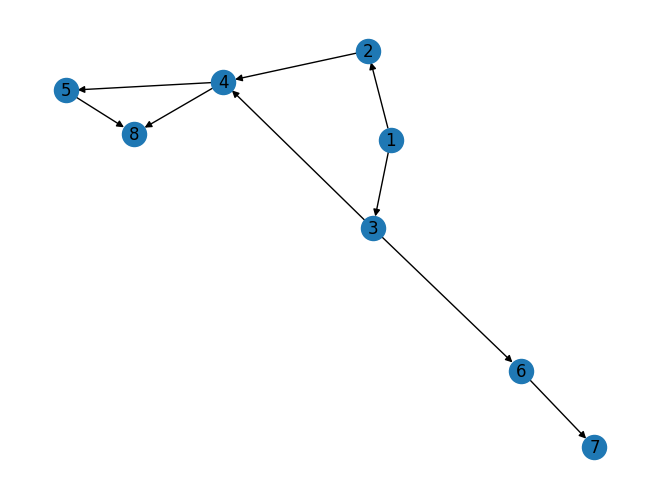

In [12]:
import matplotlib.pyplot as plt

nx.draw(sample_dag, with_labels=True)

In [13]:
partitions = PartitionTreeBuilder(sample_dag).build()

def dict_to_str(d, tabs=0):
  offset = '  '*tabs
  string = ""
  if isinstance(d, dict):
    string += "[\n"
    for k, v in d.items():
      string += f"{offset}{k}: {dict_to_str(v, tabs+1) if len(v) > 0 else None}\n"
    string += f"{offset}]"
    return string
  else:
    return d

print(dict_to_str(partitions))

[
frozenset({1, 2}): None
frozenset({3, 4, 5, 6, 7, 8}): [
  frozenset({3, 6, 7}): [
    frozenset({6}): None
    frozenset({7}): None
    ]
  frozenset({8, 4, 5}): [
    frozenset({4}): None
    frozenset({8, 5}): [
      frozenset({5}): None
      frozenset({8}): None
      ]
    ]
  ]
]


In [14]:
print(partitions)

{frozenset({1, 2}): {}, frozenset({3, 4, 5, 6, 7, 8}): {frozenset({3, 6, 7}): {frozenset({6}): {}, frozenset({7}): {}}, frozenset({8, 4, 5}): {frozenset({4}): {}, frozenset({8, 5}): {frozenset({5}): {}, frozenset({8}): {}}}}}


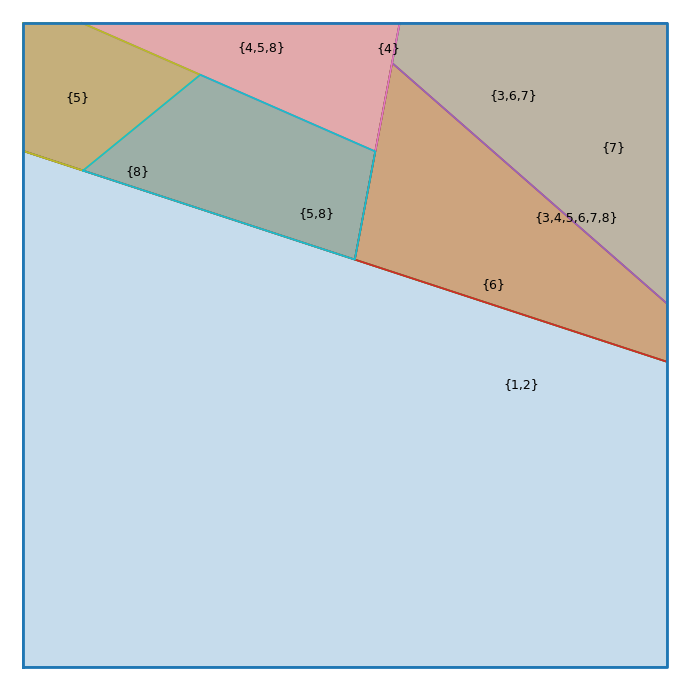

In [17]:
RecursivePowerDiagram(seed=42, hierarchy=partitions).show()